# All Uncertain Channels

## 1. Descriptions
In this experiment, let's assume that we are uncertain about the performance of all four channels Let's study how the Bayesian experimental design (BED) framework can help strengthen our knowledge and reduce our uncertainty.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import polars as pl
import polars.selectors as cs
from bedmmm.data.generator import DataGenerator
from bedmmm.experiment_designer import ExperimentDesigner
from bedmmm.model import MarketingMixModel
from thesis.plot import (
    plot_experiment_posterior_response_curve,
    plot_experiment_posterior_response_curve_multiple,
    plot_experiment_posterior_vs_ground_truth,
    plot_generated_data_on_response_curve,
    plot_posterior_response_curve,
    plot_posterior_response_curve_multiple,
    plot_posterior_vs_ground_truth,
)

In [2]:
N_DESIGN_POINTS = 4

plt.rcParams.update(
    {
        # "font.size": 22,
        # "axes.labelsize": 24,
        # "axes.titlesize": 24,
        # "legend.fontsize": 22,
        # "xtick.labelsize": 22,
        # "ytick.labelsize": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## 2. Synthetic Data Generation

In [3]:
np.random.seed(42)
generator = (
    DataGenerator(
        n_time_periods=104,  # weeks
        n_future_periods=N_DESIGN_POINTS + 13,
    )
    .generate_baseline(
        base=10,
        noise=0.0,
    )
    # Seasonality generated using sine wave
    .generate_control(
        control_effect=1,
        noise=1,
    )
    # 1. Low retention rate, high saturation, high shape
    .generate_media(
        retention_rate=0.2,
        saturation=5,
        shape=3,
        metric_lower_bound=2,
        noise=1.0,
    )
    # 2. Low retention rate, low saturation, low shape
    .generate_media(
        retention_rate=0.2,
        saturation=2,
        shape=1,
        metric_lower_bound=2,
        noise=1.0,
    )
    # 3. High retention rate, high saturation, high shape
    .generate_media(
        retention_rate=0.8,
        saturation=6,
        shape=3,
        metric_lower_bound=2,
        noise=1.0,
    )
    # 4. High retention rate, low saturation, low shape
    .generate_media(
        retention_rate=0.8,
        saturation=2,
        shape=1,
        metric_lower_bound=2,
        noise=1.0,
    )
    .generate_target(noise=3)
)

data = generator.collect()
future_data = generator.collect("future")

media_param_df, control_param_df = generator.get_parameters()

## 3. Fit a Marketing Mix Model (MMM)

Let's fit a MMM where the prior distributions of the Media channel 0 are chosen to reflect the high uncertainty while the prior distributions of all other channels are tight.

In [4]:
model_config = {
    #
    # Media channel 0 priors (high uncertainty)
    "retention_rate_lb_0": 0.1,
    "retention_rate_ub_0": 0.5,
    "shape_mu_0": 2,
    "shape_sigma_0": 1.5,
    "saturation_mu_0": 4,
    "saturation_sigma_0": 1.5,
    #
    # Media channel 1 priors (high uncertainty)
    "retention_rate_lb_1": 0.1,
    "retention_rate_ub_1": 0.5,
    "shape_mu_1": 2,
    "shape_sigma_1": 1.5,
    "saturation_mu_1": 4,
    "saturation_sigma_1": 1.5,
    #
    # Media channel 2 priors (high uncertainty)
    "retention_rate_lb_2": 0.5,
    "retention_rate_ub_2": 0.9,
    "shape_mu_2": 2,
    "shape_sigma_2": 1.5,
    "saturation_mu_2": 4,
    "saturation_sigma_2": 1.5,
    #
    # Media channel 3 priors (high uncertainty)
    "retention_rate_lb_3": 0.5,
    "retention_rate_ub_3": 0.9,
    "shape_mu_3": 2,
    "shape_sigma_3": 1.5,
    "saturation_mu_3": 4,
    "saturation_sigma_3": 1.5,
    #
    # Control
    "gamma_mu_0": 1.0,
    "gamma_sigma_0": 1.0,
    #
    # Baseline
    "baseline_mu": 10.0,
    "baseline_sigma": 0.1,
    #
    # Observation noise
    "obs_sigma": 3,
}
sampler_config = {
    "draws": 15_000,
    "tune": 5_000,
    "chains": 4,
    "cores": 4,
    "target_accept": 0.975,
}

In [5]:
model = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)

idata = model.fit(
    data.drop(["y"]).to_pandas(),
    data["y"].to_pandas(),
    random_seed=42,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 5_000 tune and 15_000 draw iterations (20_000 + 60_000 draws total) took 436 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

In [6]:
summary_df = az.summary(idata)
# az.plot_trace(idata, figsize=(15, 20));

In [7]:
summary_df.reset_index().query(
    "index.str.contains('saturation|shape|retention_rate')"
)

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
105,retention_rates[0],0.257,0.107,0.100,0.446,0.000,0.000,107673.0,37135.0,1.0
106,retention_rates[1],0.324,0.112,0.136,0.500,0.000,0.000,107188.0,38322.0,1.0
107,retention_rates[2],0.689,0.111,0.500,0.869,0.000,0.000,120797.0,39474.0,1.0
108,retention_rates[3],0.746,0.108,0.551,0.900,0.000,0.000,94591.0,38765.0,1.0
109,shapes[0],2.893,1.025,1.026,4.787,0.003,0.004,95910.0,38482.0,1.0
110,shapes[1],2.558,1.213,0.383,4.802,0.004,0.005,59844.0,26511.0,1.0
111,shapes[2],2.894,1.274,0.402,5.213,0.006,0.006,44330.0,20455.0,1.0
112,shapes[3],2.444,1.349,0.000,4.646,0.006,0.005,44706.0,24720.0,1.0
113,saturations[0],4.919,1.186,2.707,7.149,0.004,0.006,76495.0,33060.0,1.0
114,saturations[1],3.636,1.186,1.402,5.848,0.004,0.006,67128.0,28679.0,1.0


### 3.1 Comparison between Posterior Distributions and Ground Truth

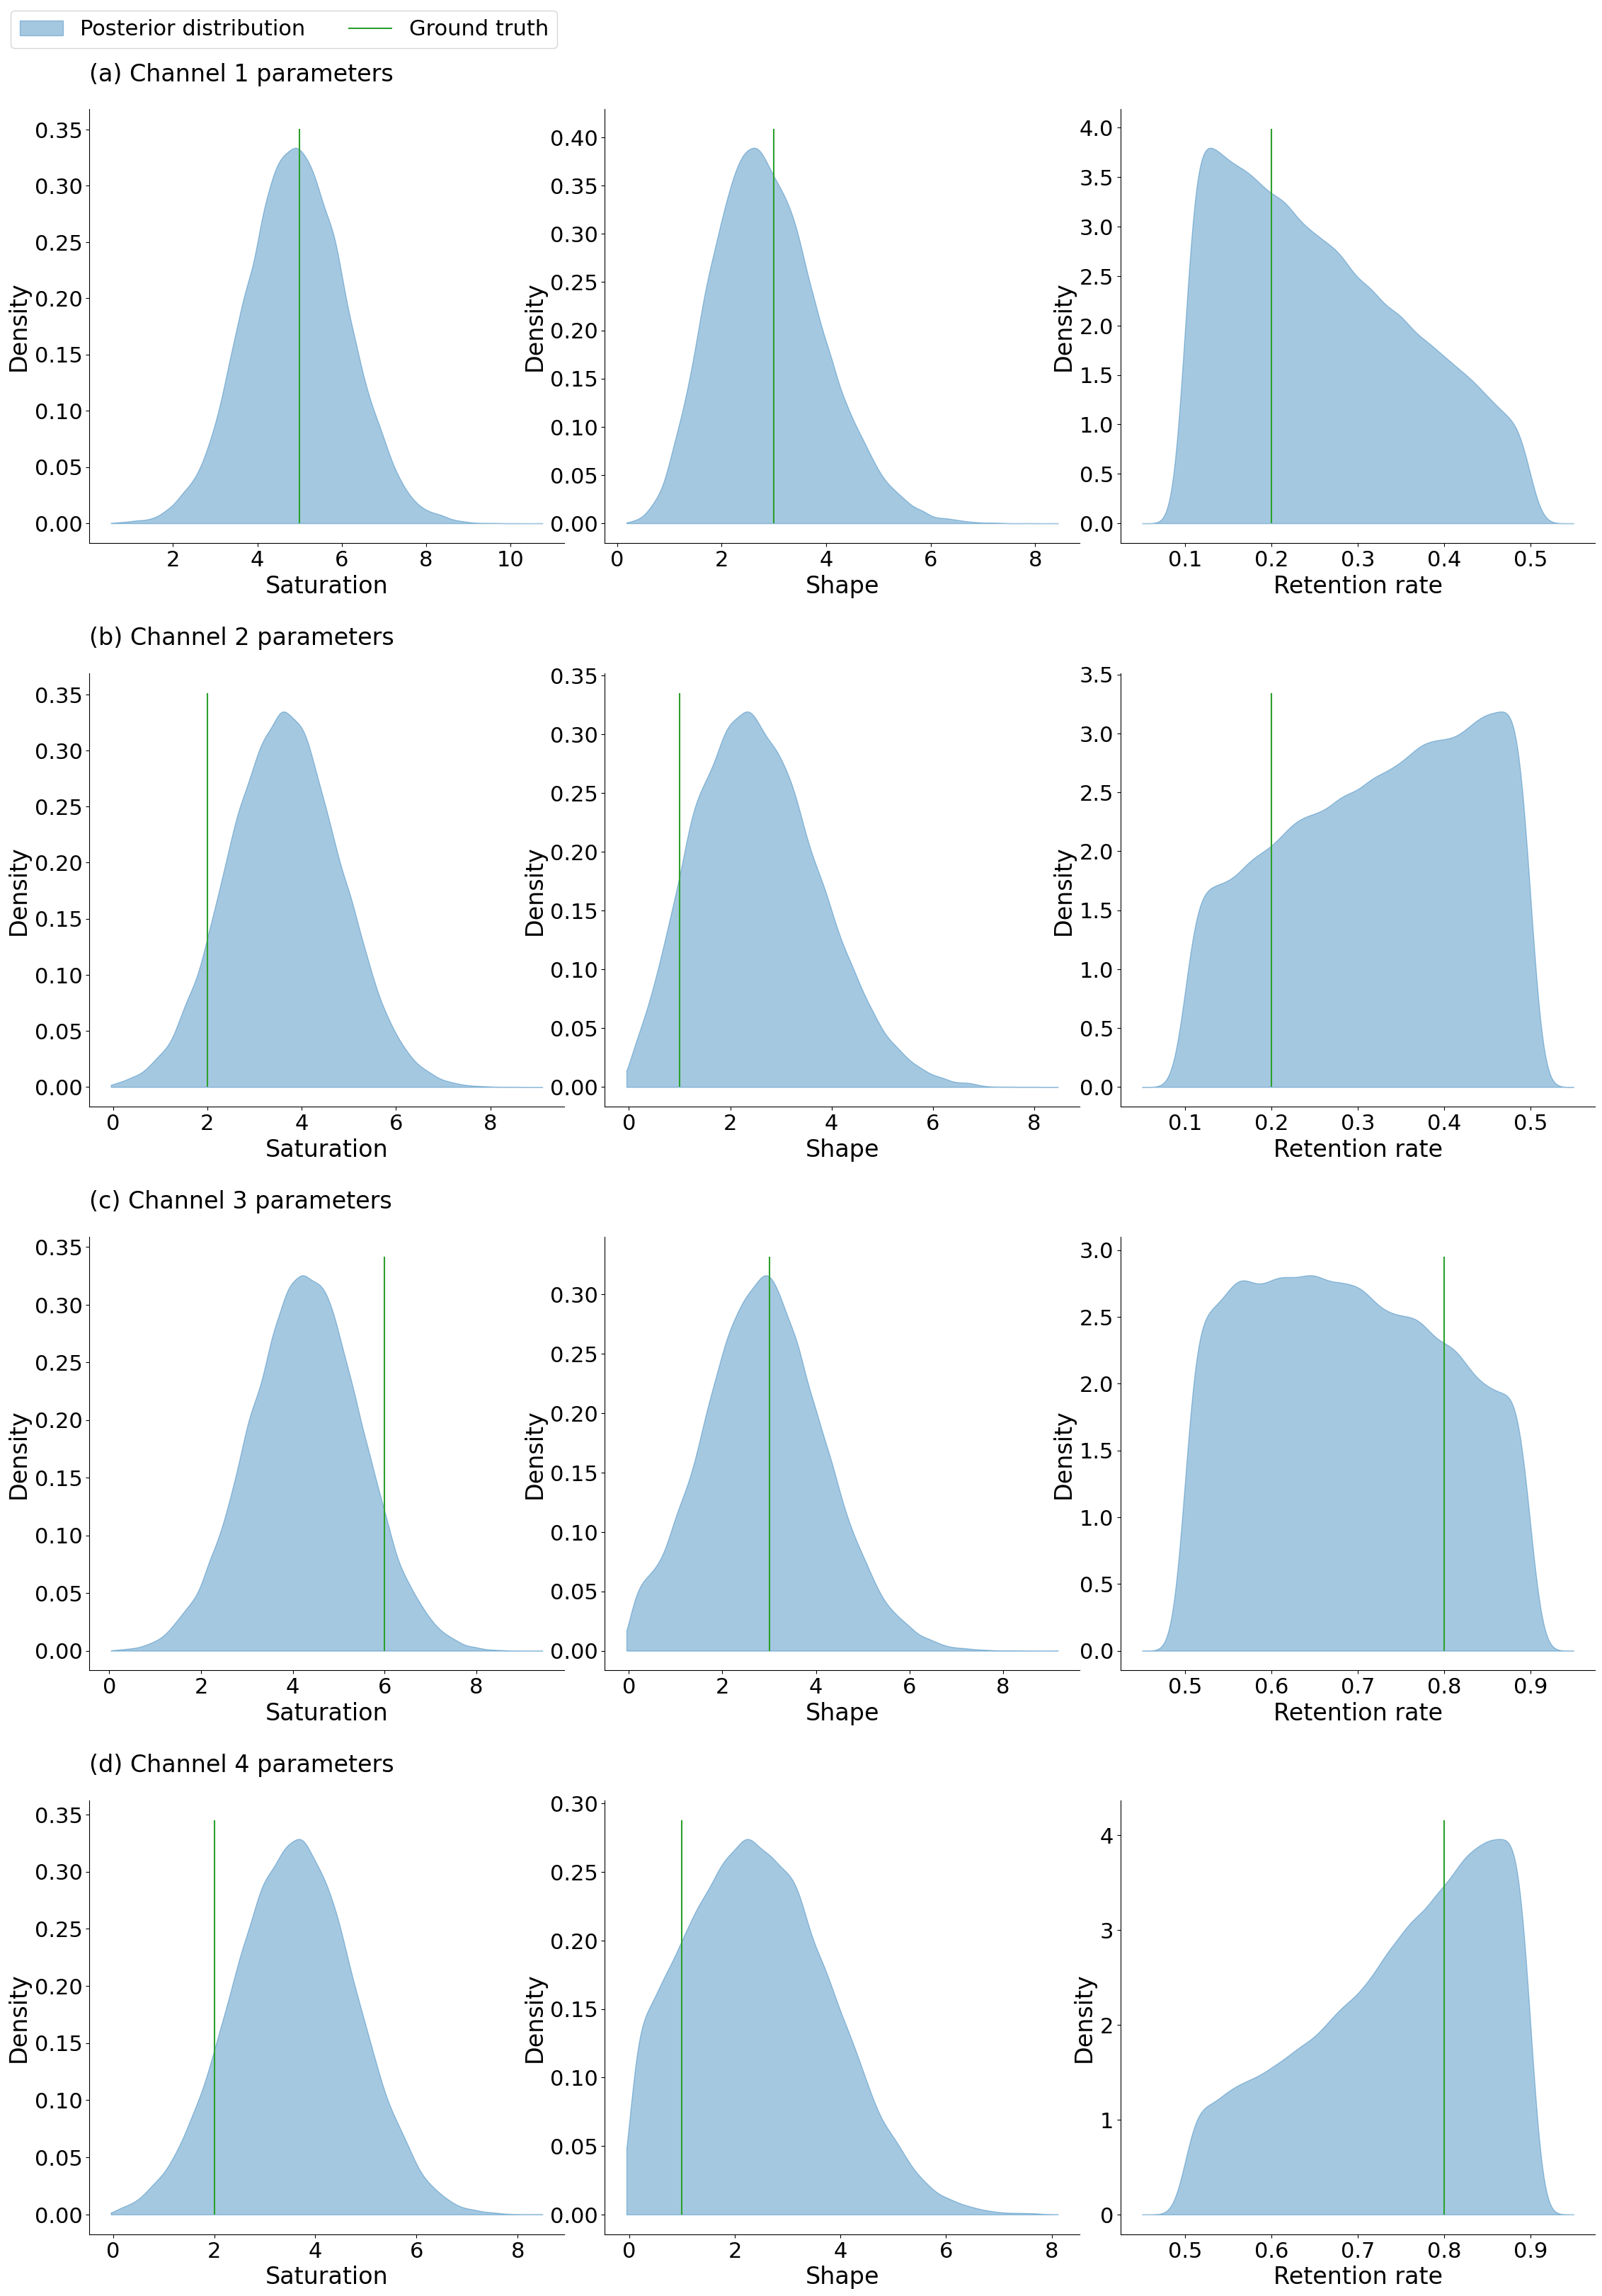

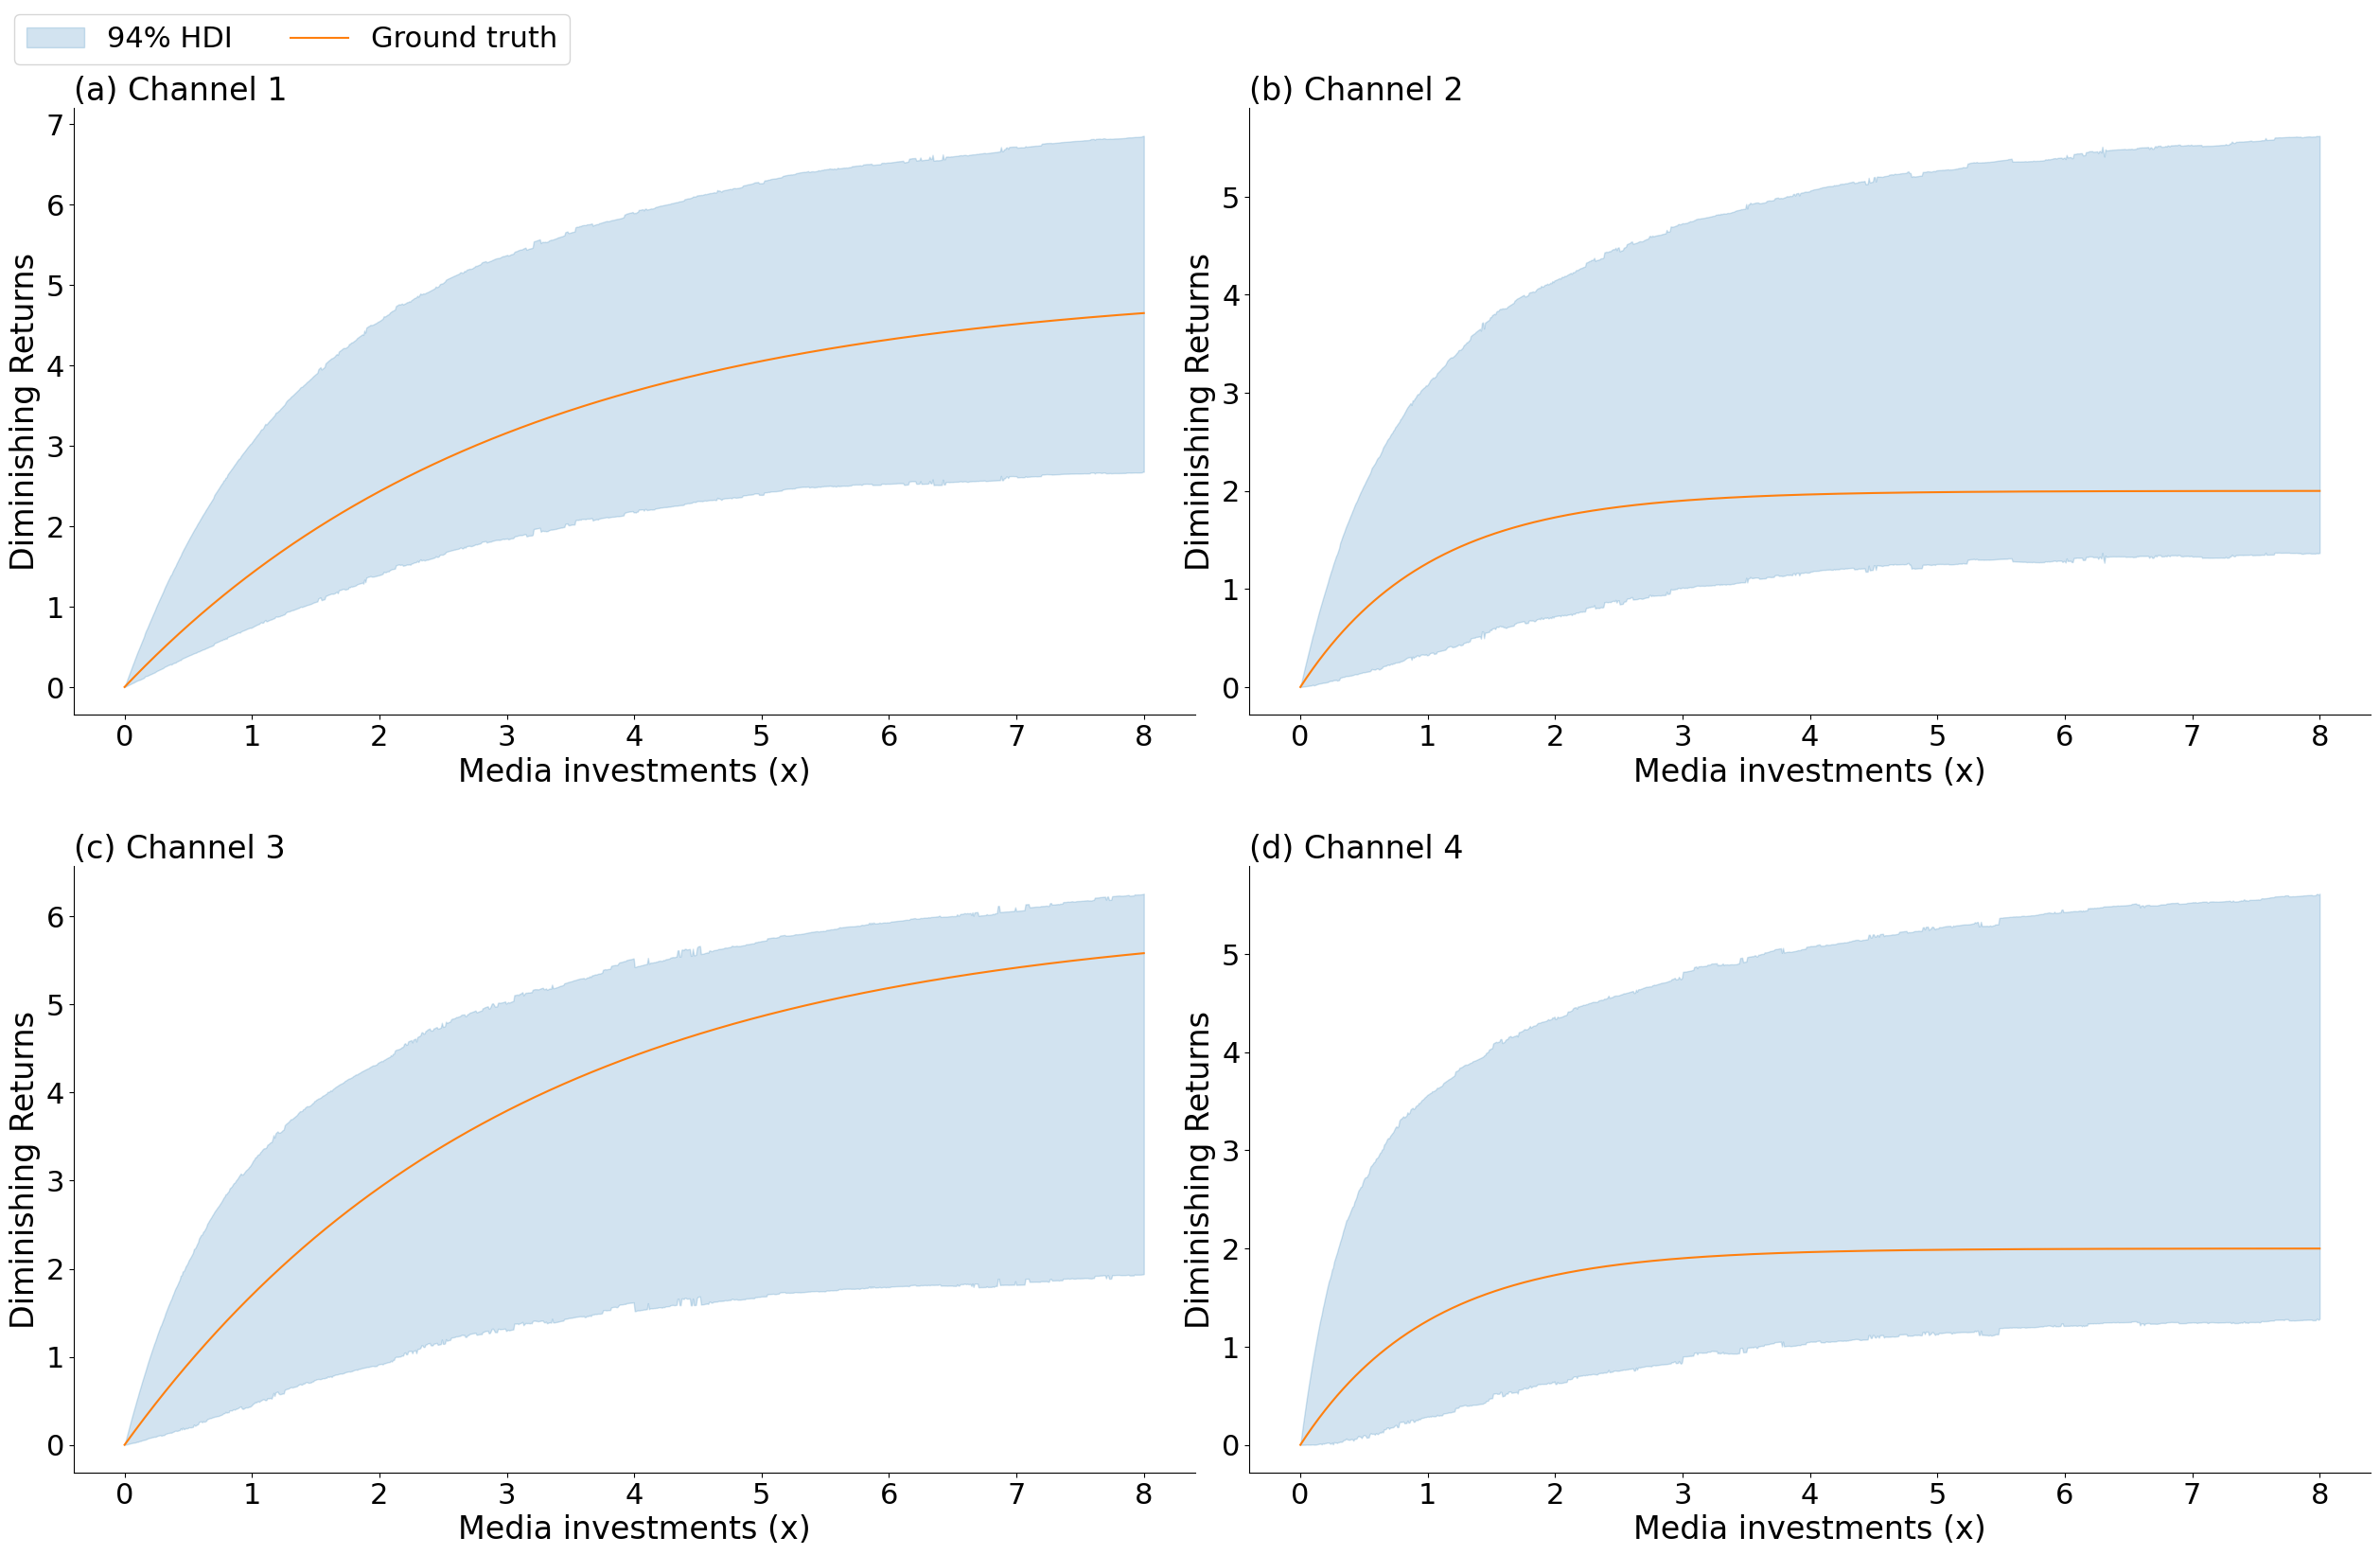

In [8]:
plot_posterior_vs_ground_truth(
    idata,
    media_param_df,
    ["media_0", "media_1", "media_2", "media_3"],
    figsize=(22, 32),
    subplot_adjust_kwargs={"top": 0.95, "hspace": 0.3},
)

plot_posterior_response_curve_multiple(
    idata,
    media_param_df=media_param_df,
    media_feature_names=["media_0", "media_1", "media_2", "media_3"],
)

## 4. Bayesian Experiment Design (BED)

When generating the synthetic data, a dataset, which we call "future data", is also generated along with the data used to fit the model above. "Future data" is not used to fit the model but considered as the budget planning for marketing investments. This helps us quantify the difference between the investments recommended in the optimal experiment and the planned budget (which the marketers are already comfortable of investing).

In [9]:
future_data = generator.collect(data_type="future")

### 4.0 What if we don't run any experiments?

Let's fit a model with 104 + 12 weeks of data without running any experiments at all. This model represents our state of knowledge without the integration of the BED framework.

In [10]:
data_without_dhat = pl.concat([data, future_data], how="vertical")

model_without_dhat = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)

idata_without_dhat = model_without_dhat.fit(
    data_without_dhat.drop(["y"]).to_pandas(),
    data_without_dhat["y"].to_pandas(),
    random_seed=42,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 5_000 tune and 15_000 draw iterations (20_000 + 60_000 draws total) took 480 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

In [11]:
summary_without_dhat_df = az.summary(idata_without_dhat)

In [12]:
summary_without_dhat_df.reset_index().query(
    "index.str.contains('saturation|shape|retention_rate')"
)

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
122,retention_rates[0],0.249,0.107,0.100,0.443,0.000,0.000,72571.0,37107.0,1.0
123,retention_rates[1],0.331,0.111,0.141,0.500,0.000,0.000,75980.0,38084.0,1.0
124,retention_rates[2],0.684,0.110,0.500,0.864,0.000,0.000,84878.0,37317.0,1.0
125,retention_rates[3],0.757,0.105,0.560,0.900,0.000,0.000,80361.0,38217.0,1.0
126,shapes[0],2.849,1.050,0.933,4.768,0.004,0.004,70533.0,34173.0,1.0
127,shapes[1],2.329,1.249,0.075,4.488,0.005,0.005,48622.0,24015.0,1.0
128,shapes[2],2.976,1.243,0.589,5.303,0.007,0.007,26306.0,11290.0,1.0
129,shapes[3],2.326,1.334,0.002,4.530,0.006,0.005,43261.0,25480.0,1.0
130,saturations[0],4.755,1.160,2.573,6.929,0.006,0.009,49098.0,24887.0,1.0
131,saturations[1],3.373,1.169,1.168,5.578,0.006,0.006,39155.0,18106.0,1.0


### 4.1 Optimize for response curve parameters

In [13]:
future_control_vars = (
    future_data.slice(0, 1)
    .select(cs.starts_with("control_"))
    .to_numpy()
    .flatten()
)
future_media_data_df = future_data.slice(0, 4).select(cs.starts_with("media_"))

In [14]:
d_hat_curve_param = (
    ExperimentDesigner(n_media_channels=4, c=future_control_vars)
    .add_posterior_samples(idata)
    .configure_experiment_space(
        lower_bound=np.zeros((N_DESIGN_POINTS, 4)),
        upper_bound=(
            future_media_data_df.sum().to_numpy()
            * np.ones((N_DESIGN_POINTS, 1))
            * 2
        ),
        total_budget=future_media_data_df.to_numpy().sum() * 2,
        n_design_points=N_DESIGN_POINTS,
    )
    # .configure_regularization(
    #     x_0=future_media_data,
    #     regularized_type="cost",
    #     regularized_weight=0.1,
    # )
    .configure_target_variables(
        [
            "saturation",
            "shape",
            # "retention_rate",
        ]
    )
    .find_optimal_experiment()
)
print(f"Optimal experiment found for curve parameters: {d_hat_curve_param}")

# Add the experiment data to the synthetic generated dataset
d_hat_curve_param = d_hat_curve_param.reshape((4, -1))
generator_with_dhat_curve_param = (
    generator
    #
    .generate_new_observation(
        x=d_hat_curve_param[0, :],
        c=(
            future_data.slice(0, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
    .generate_new_observation(
        x=d_hat_curve_param[1, :],
        c=(
            future_data.slice(1, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
    .generate_new_observation(
        x=d_hat_curve_param[2, :],
        c=(
            future_data.slice(2, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
    .generate_new_observation(
        x=d_hat_curve_param[3, :],
        c=(
            future_data.slice(3, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
)
data_with_dhat_curve_param = pl.concat(
    [generator_with_dhat_curve_param.collect(), future_data.slice(4)],
    how="vertical",
)

model_with_dhat_curve_param = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)

idata_with_dhat_curve_param = model_with_dhat_curve_param.fit(
    data_with_dhat_curve_param.drop(["y"]).to_pandas(),
    data_with_dhat_curve_param["y"].to_pandas(),
    random_seed=42,
)

summary_with_dhat_curve_param_df = az.summary(idata_with_dhat_curve_param)

/Users/luu/Documents/master thesis/bedmmm/src/bedmmm/experiment_designer.py:590: RuntimeWarning: divide by zero encountered in divide
  return np.log(numerator / denominator.mean(axis=1)).mean()
/Users/luu/Documents/master thesis/bedmmm/.venv/lib/python3.13/site-packages/scipy/_lib/pyprima/common/linalg.py:61: RuntimeWarning: overflow encountered in matmul
  return x@y
/Users/luu/Documents/master thesis/bedmmm/.venv/lib/python3.13/site-packages/scipy/_lib/pyprima/common/linalg.py:61: RuntimeWarning: invalid value encountered in matmul
  return x@y
/Users/luu/Documents/master thesis/bedmmm/.venv/lib/python3.13/site-packages/scipy/_lib/pyprima/common/linalg.py:30: RuntimeWarning: invalid value encountered in dot
  return np.dot(x, y)
/Users/luu/Documents/master thesis/bedmmm/src/bedmmm/model.py:376: RuntimeWarning: overflow encountered in exp
  saturations * (1 - np.exp(-x_transformed / shapes)), axis=1
/Users/luu/Documents/master thesis/bedmmm/.venv/lib/python3.13/site-packages/scipy/st

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -0.19418295059948437
       x: [ 6.816e+00  1.198e+01 ... -5.749e-16 -5.833e-16]
    nfev: 153
   maxcv: 6.489064179866247e-16
Optimal experiment found for curve parameters: [ 6.81613201e+00  1.19824937e+01 -6.03941876e-16 -6.06195160e-16
  8.46402040e+00  6.32723863e+00 -6.48906418e-16 -6.44237750e-16
  4.42448996e+00  5.97644135e+00 -6.40303609e-16 -6.12343120e-16
  3.85069748e+00  7.10983646e+00 -5.74912714e-16 -5.83277006e-16]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 5_000 tune and 15_000 draw iterations (20_000 + 60_000 draws total) took 317 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

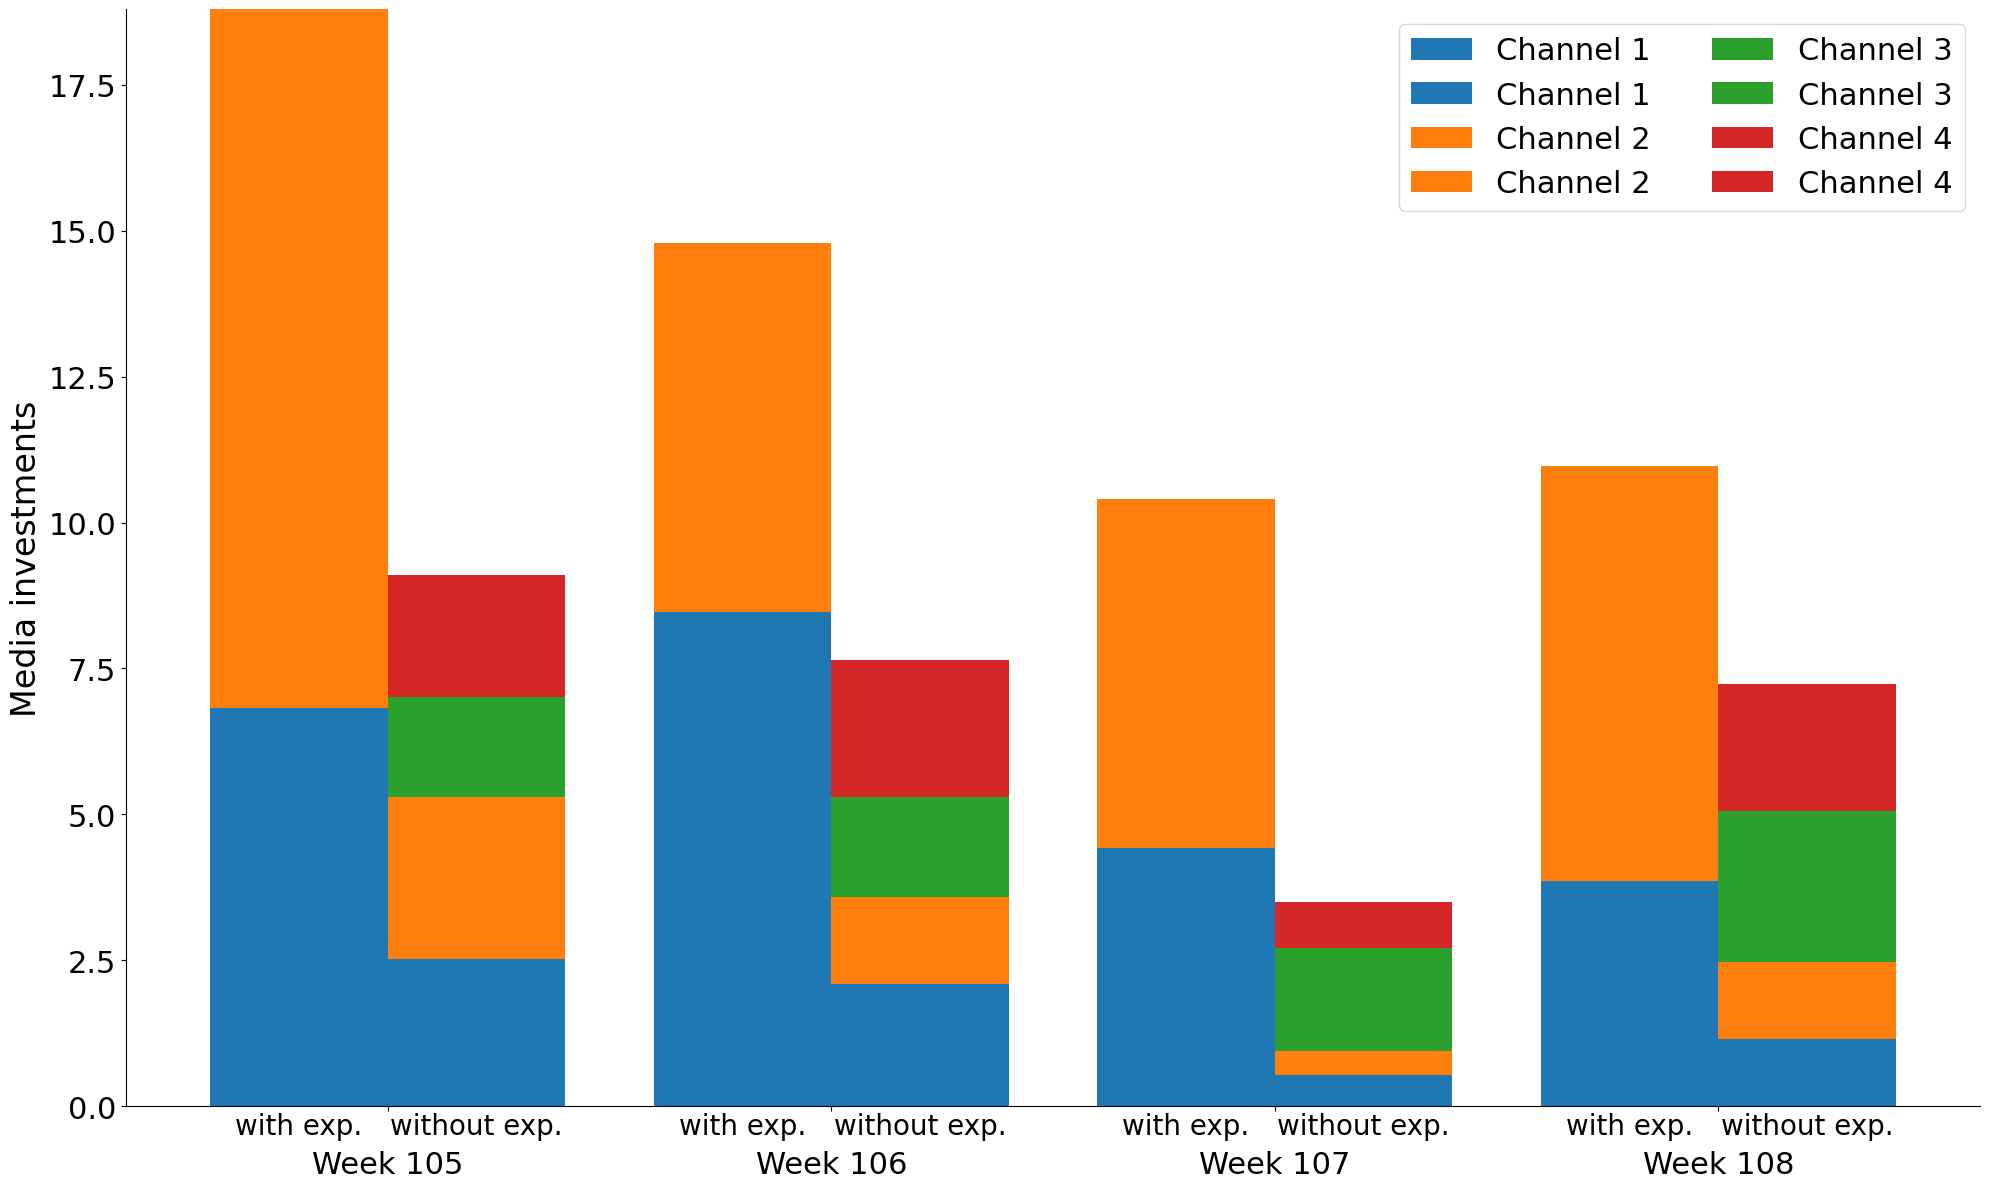

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.figure(figsize=(20, 12))

# Data
weeks = ["Week 105", "Week 106", "Week 107", "Week 108"]

x = np.arange(len(weeks))
width = 0.4

experimental_bottom = np.zeros(len(weeks))
normal_bottom = np.zeros(len(weeks))
for channel_id in range(4):
    experiment_investments = d_hat_curve_param[:, channel_id]
    normal_investments = future_media_data_df.select(
        f"media_{channel_id}"
    ).to_numpy().flatten()

    plt.bar(
        x - width / 2,
        experiment_investments,
        width,
        bottom=experimental_bottom,
        label=f"Channel {channel_id + 1}",
        color=f"C{channel_id}",
    )
    plt.bar(
        x + width / 2,
        normal_investments,
        width,
        bottom=normal_bottom,
        label=f"Channel {channel_id + 1}",
        color=f"C{channel_id}",
    )
    experimental_bottom += experiment_investments
    normal_bottom += normal_investments

ax = plt.gca()

# ===== 2-layer X axis =====

# Major ticks → weeks (lower row)
ax.set_xticks(x)
ax.set_xticklabels(labels=weeks)
ax.tick_params(axis="x", which="major", pad=28)

ax.tick_params(axis="both", which="major", labelsize=22)

# Minor ticks → S1 / S2 (upper row)
minor_positions = np.ravel(np.column_stack([x - width / 2, x + width / 2]))
minor_labels = ["with exp.", "without exp."] * len(weeks)

ax.xaxis.set_minor_locator(FixedLocator(minor_positions))
ax.xaxis.set_minor_formatter(FixedFormatter(minor_labels))
ax.tick_params(axis="x", which="minor", pad=4, length=0, labelsize=20)

# Formatting
plt.xticks(x)
plt.ylabel("Media investments", size=24)

plt.legend(ncol=2, fontsize=22)
plt.tight_layout()
plt.show()

In [15]:
summary_with_dhat_curve_param_df.reset_index().query(
    "index.str.contains('saturation|shape|retention_rate')"
)

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
122,retention_rates[0],0.267,0.109,0.100,0.455,0.000,0.000,97974.0,36258.0,1.0
123,retention_rates[1],0.341,0.109,0.150,0.500,0.000,0.000,92014.0,39095.0,1.0
124,retention_rates[2],0.675,0.106,0.500,0.852,0.000,0.000,77889.0,38855.0,1.0
125,retention_rates[3],0.748,0.108,0.551,0.900,0.000,0.000,70617.0,40455.0,1.0
126,shapes[0],2.825,1.031,1.002,4.775,0.003,0.004,77264.0,36454.0,1.0
127,shapes[1],2.268,1.191,0.184,4.442,0.005,0.005,50041.0,24202.0,1.0
128,shapes[2],2.939,1.227,0.680,5.279,0.006,0.006,37864.0,16397.0,1.0
129,shapes[3],2.303,1.338,0.002,4.524,0.006,0.005,40362.0,23434.0,1.0
130,saturations[0],4.754,1.134,2.573,6.842,0.004,0.005,67194.0,32538.0,1.0
131,saturations[1],3.375,1.134,1.177,5.442,0.005,0.005,44341.0,22408.0,1.0


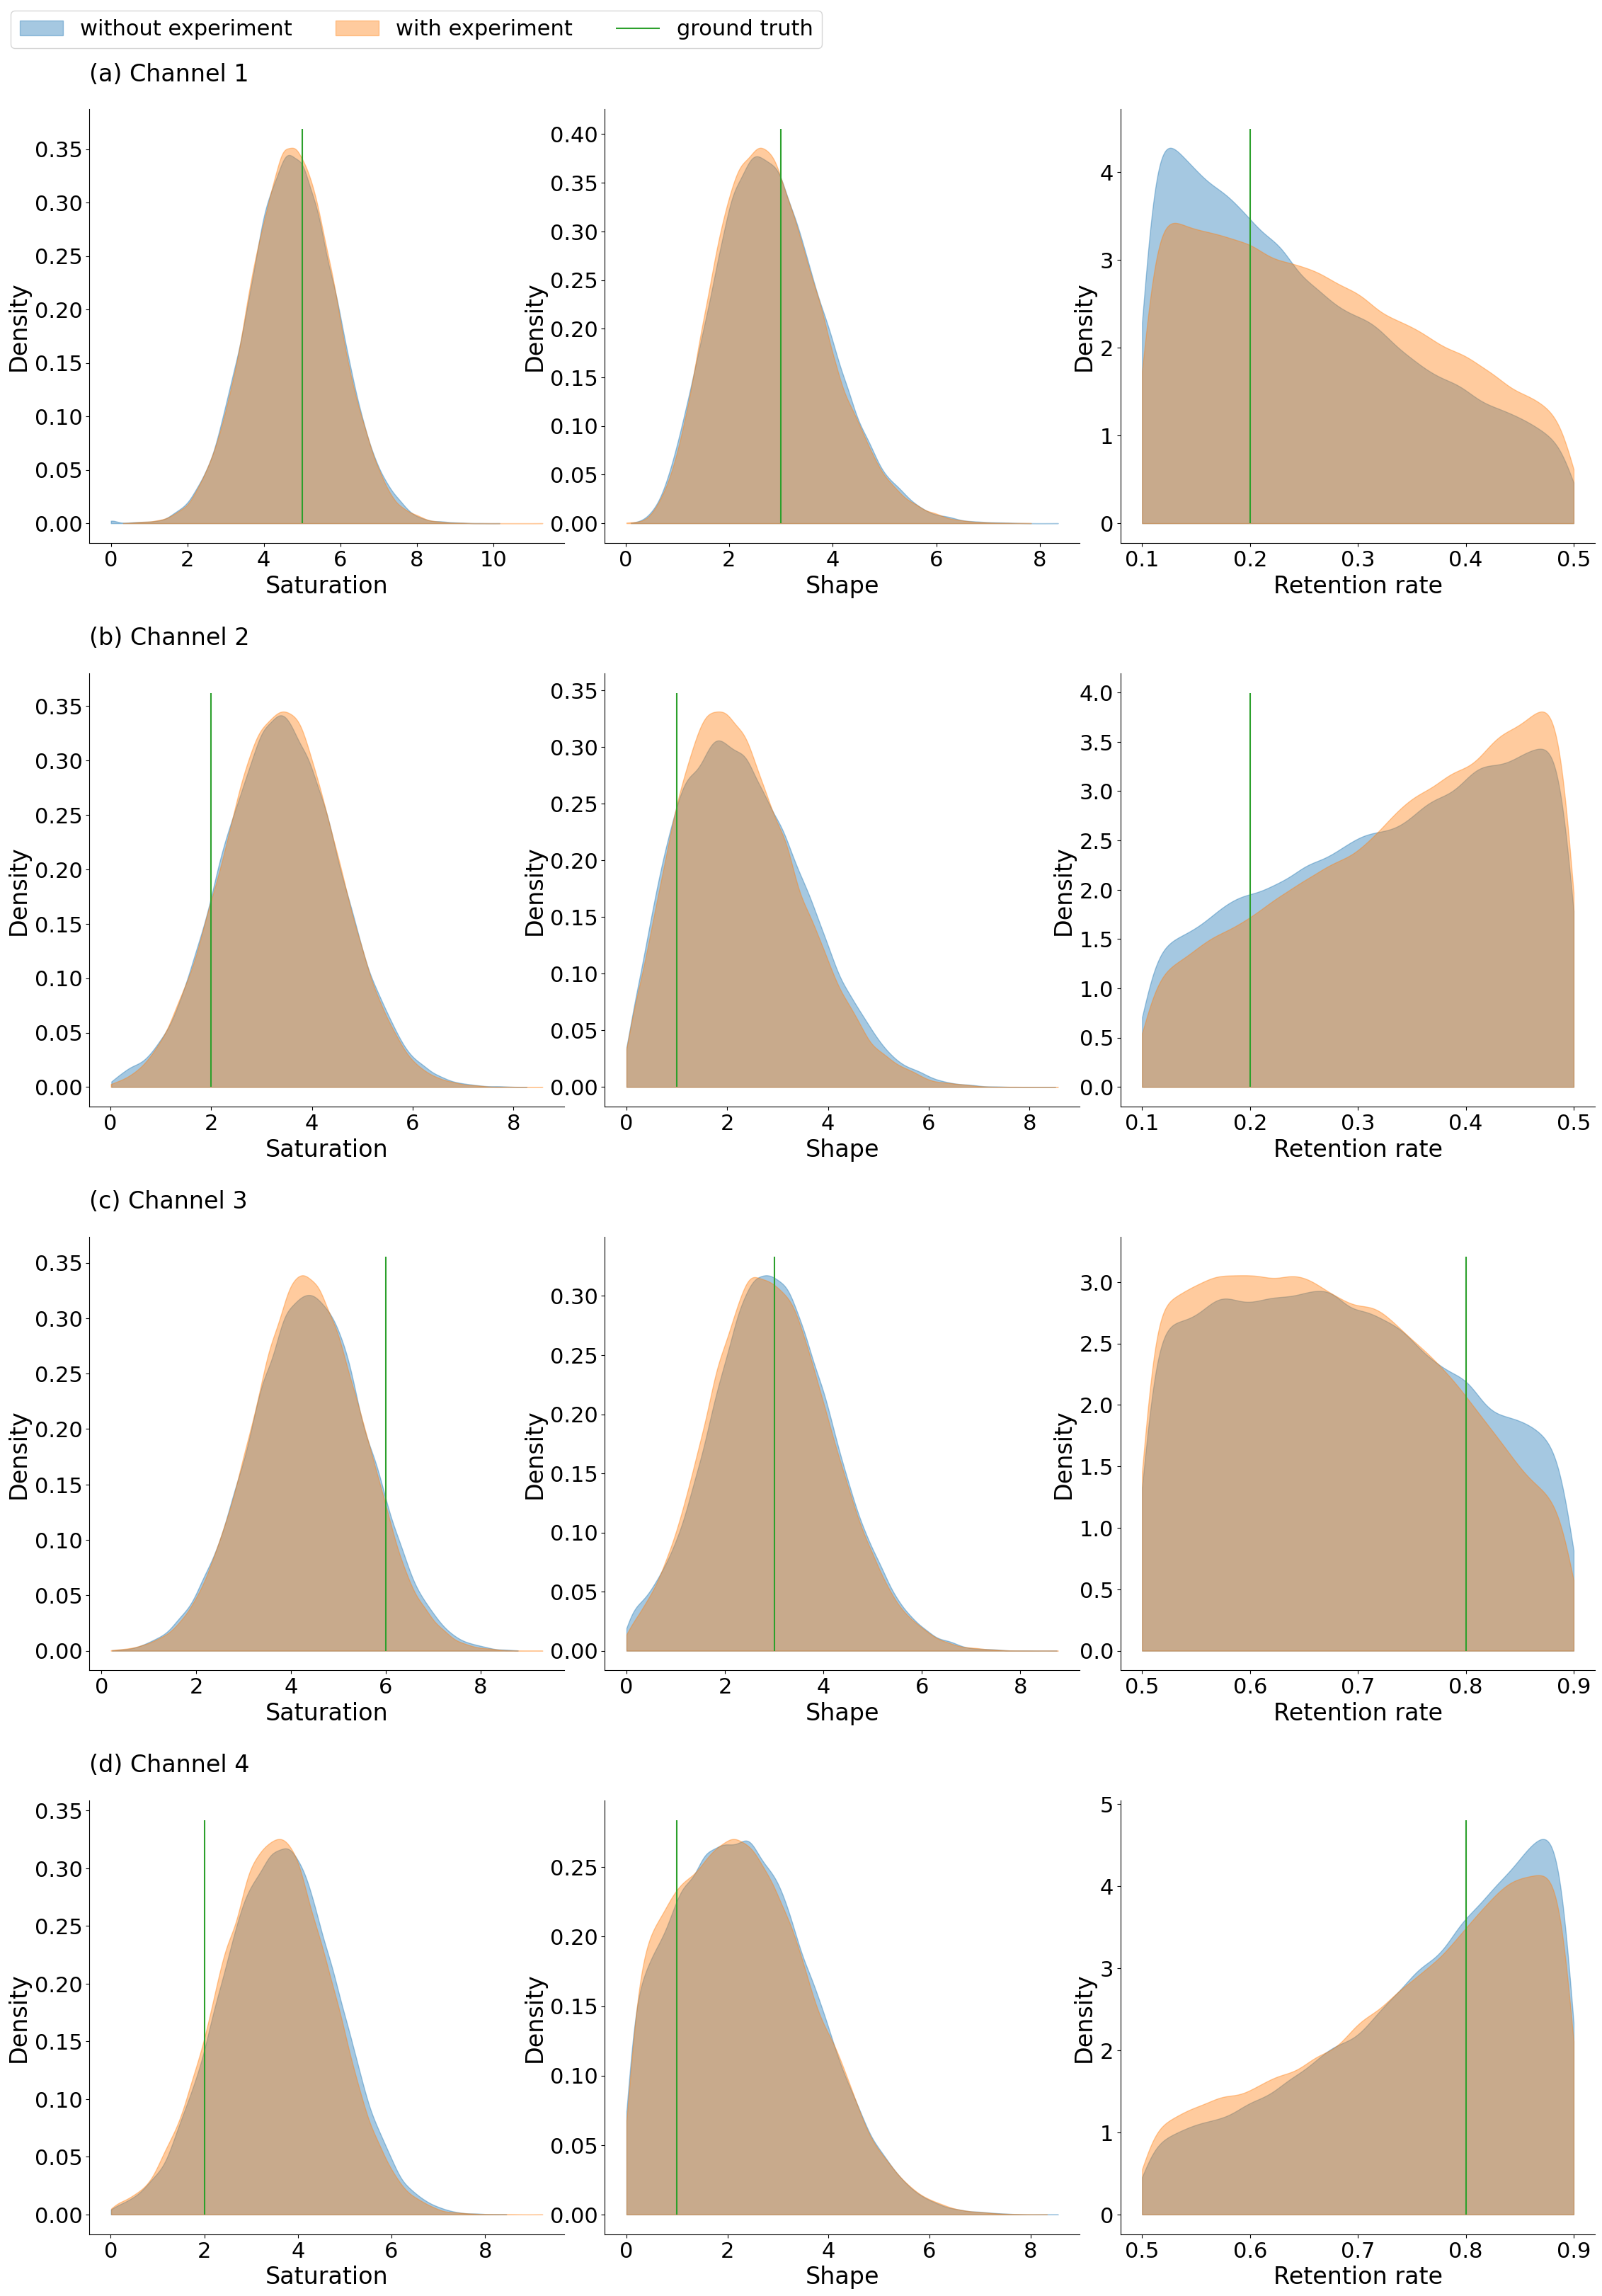

In [22]:
plot_experiment_posterior_vs_ground_truth(
    idata_without_experiment=idata_without_dhat,
    idata_with_experiment=idata_with_dhat_curve_param,
    media_param_df=media_param_df,
    media_feature_names=["media_0", "media_1", "media_2", "media_3"],
    figsize=(22, 32),
    subplot_adjust_kwargs={"top": 0.95, "hspace": 0.3},
)

# plot_experiment_posterior_response_curve_multiple(
#     idata_without_experiment=idata_without_dhat,
#     idata_with_experiment=idata_with_dhat_curve_param,
#     media_param_df=media_param_df,
#     media_feature_names=["media_0", "media_1", "media_2", "media_3"],
# )

### 4.2 Optimize for retention rate parameter

In [17]:
d_hat_retention_rate = (
    ExperimentDesigner(n_media_channels=4, c=future_control_vars)
    .add_posterior_samples(idata)
    .configure_experiment_space(
        lower_bound=np.zeros((N_DESIGN_POINTS, 4)),
        upper_bound=(
            future_media_data_df.sum().to_numpy()
            * np.ones((N_DESIGN_POINTS, 1))
            * 2
        ),
        total_budget=future_media_data_df.to_numpy().sum() * 2,
        n_design_points=N_DESIGN_POINTS,
    )
    # .configure_regularization(
    #     x_0=future_media_data,
    #     regularized_type="cost",
    #     regularized_weight=0.1,
    # )
    .configure_target_variables(
        [
            # "saturation",
            # "shape",
            "retention_rate",
        ]
    )
    .find_optimal_experiment()
)
print(
    f"Optimal experiment found for retention rate parameter: "
    f"{d_hat_retention_rate}"
)

# Add the experiment data to the synthetic generated dataset
d_hat_retention_rate = d_hat_retention_rate.reshape((4, -1))
generator_with_dhat_retention_rate = (
    generator
    #
    .generate_new_observation(
        x=d_hat_retention_rate[0, :],
        c=(
            future_data.slice(0, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
    .generate_new_observation(
        x=d_hat_retention_rate[1, :],
        c=(
            future_data.slice(1, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
    .generate_new_observation(
        x=d_hat_retention_rate[2, :],
        c=(
            future_data.slice(2, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
    .generate_new_observation(
        x=d_hat_retention_rate[3, :],
        c=(
            future_data.slice(3, 1)
            .select(cs.starts_with("control_"))
            .to_numpy()
            .flatten()
        ),
    )
)
data_with_dhat_retention_rate = pl.concat(
    [generator_with_dhat_retention_rate.collect(), future_data.slice(4)],
    how="vertical",
)

model_with_dhat_retention_rate = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)

idata_with_dhat_retention_rate = model_with_dhat_retention_rate.fit(
    data_with_dhat_retention_rate.drop(["y"]).to_pandas(),
    data_with_dhat_retention_rate["y"].to_pandas(),
    random_seed=42,
)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -0.1689552818233252
       x: [ 1.261e+01  1.198e+01 ... -1.142e-15 -1.134e-15]
    nfev: 77
   maxcv: 1.7763568394002505e-15
Optimal experiment found for retention rate parameter: [ 1.26062050e+01  1.19824937e+01 -1.13678569e-15 -1.13014163e-15
 -1.13616996e-15 -1.33226763e-15 -1.14088828e-15 -1.10748418e-15
 -1.08356743e-15 -1.12462030e-15 -1.15243148e-15 -1.13590088e-15
 -1.17389311e-15 -1.17709659e-15 -1.14236360e-15 -1.13429305e-15]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 5_000 tune and 15_000 draw iterations (20_000 + 60_000 draws total) took 331 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

In [18]:
summary_with_dhat_retention_rate_df = az.summary(
    idata_with_dhat_retention_rate
)

In [19]:
summary_with_dhat_retention_rate_df.reset_index().query(
    "index.str.contains('saturation|shape|retention_rate')"
)

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
122,retention_rates[0],0.248,0.104,0.100,0.435,0.000,0.000,86893.0,36458.0,1.0
123,retention_rates[1],0.327,0.110,0.143,0.500,0.000,0.000,79694.0,38580.0,1.0
124,retention_rates[2],0.677,0.107,0.500,0.857,0.000,0.000,74284.0,39149.0,1.0
125,retention_rates[3],0.749,0.109,0.549,0.900,0.000,0.000,77448.0,41052.0,1.0
126,shapes[0],2.664,1.022,0.835,4.556,0.004,0.004,72755.0,37437.0,1.0
127,shapes[1],2.125,1.226,0.047,4.292,0.005,0.005,52209.0,27307.0,1.0
128,shapes[2],2.884,1.229,0.558,5.143,0.006,0.006,40117.0,18898.0,1.0
129,shapes[3],2.246,1.337,0.001,4.481,0.006,0.005,43082.0,24980.0,1.0
130,saturations[0],4.755,1.123,2.637,6.853,0.004,0.006,72422.0,33788.0,1.0
131,saturations[1],3.402,1.136,1.289,5.574,0.005,0.006,47361.0,23368.0,1.0


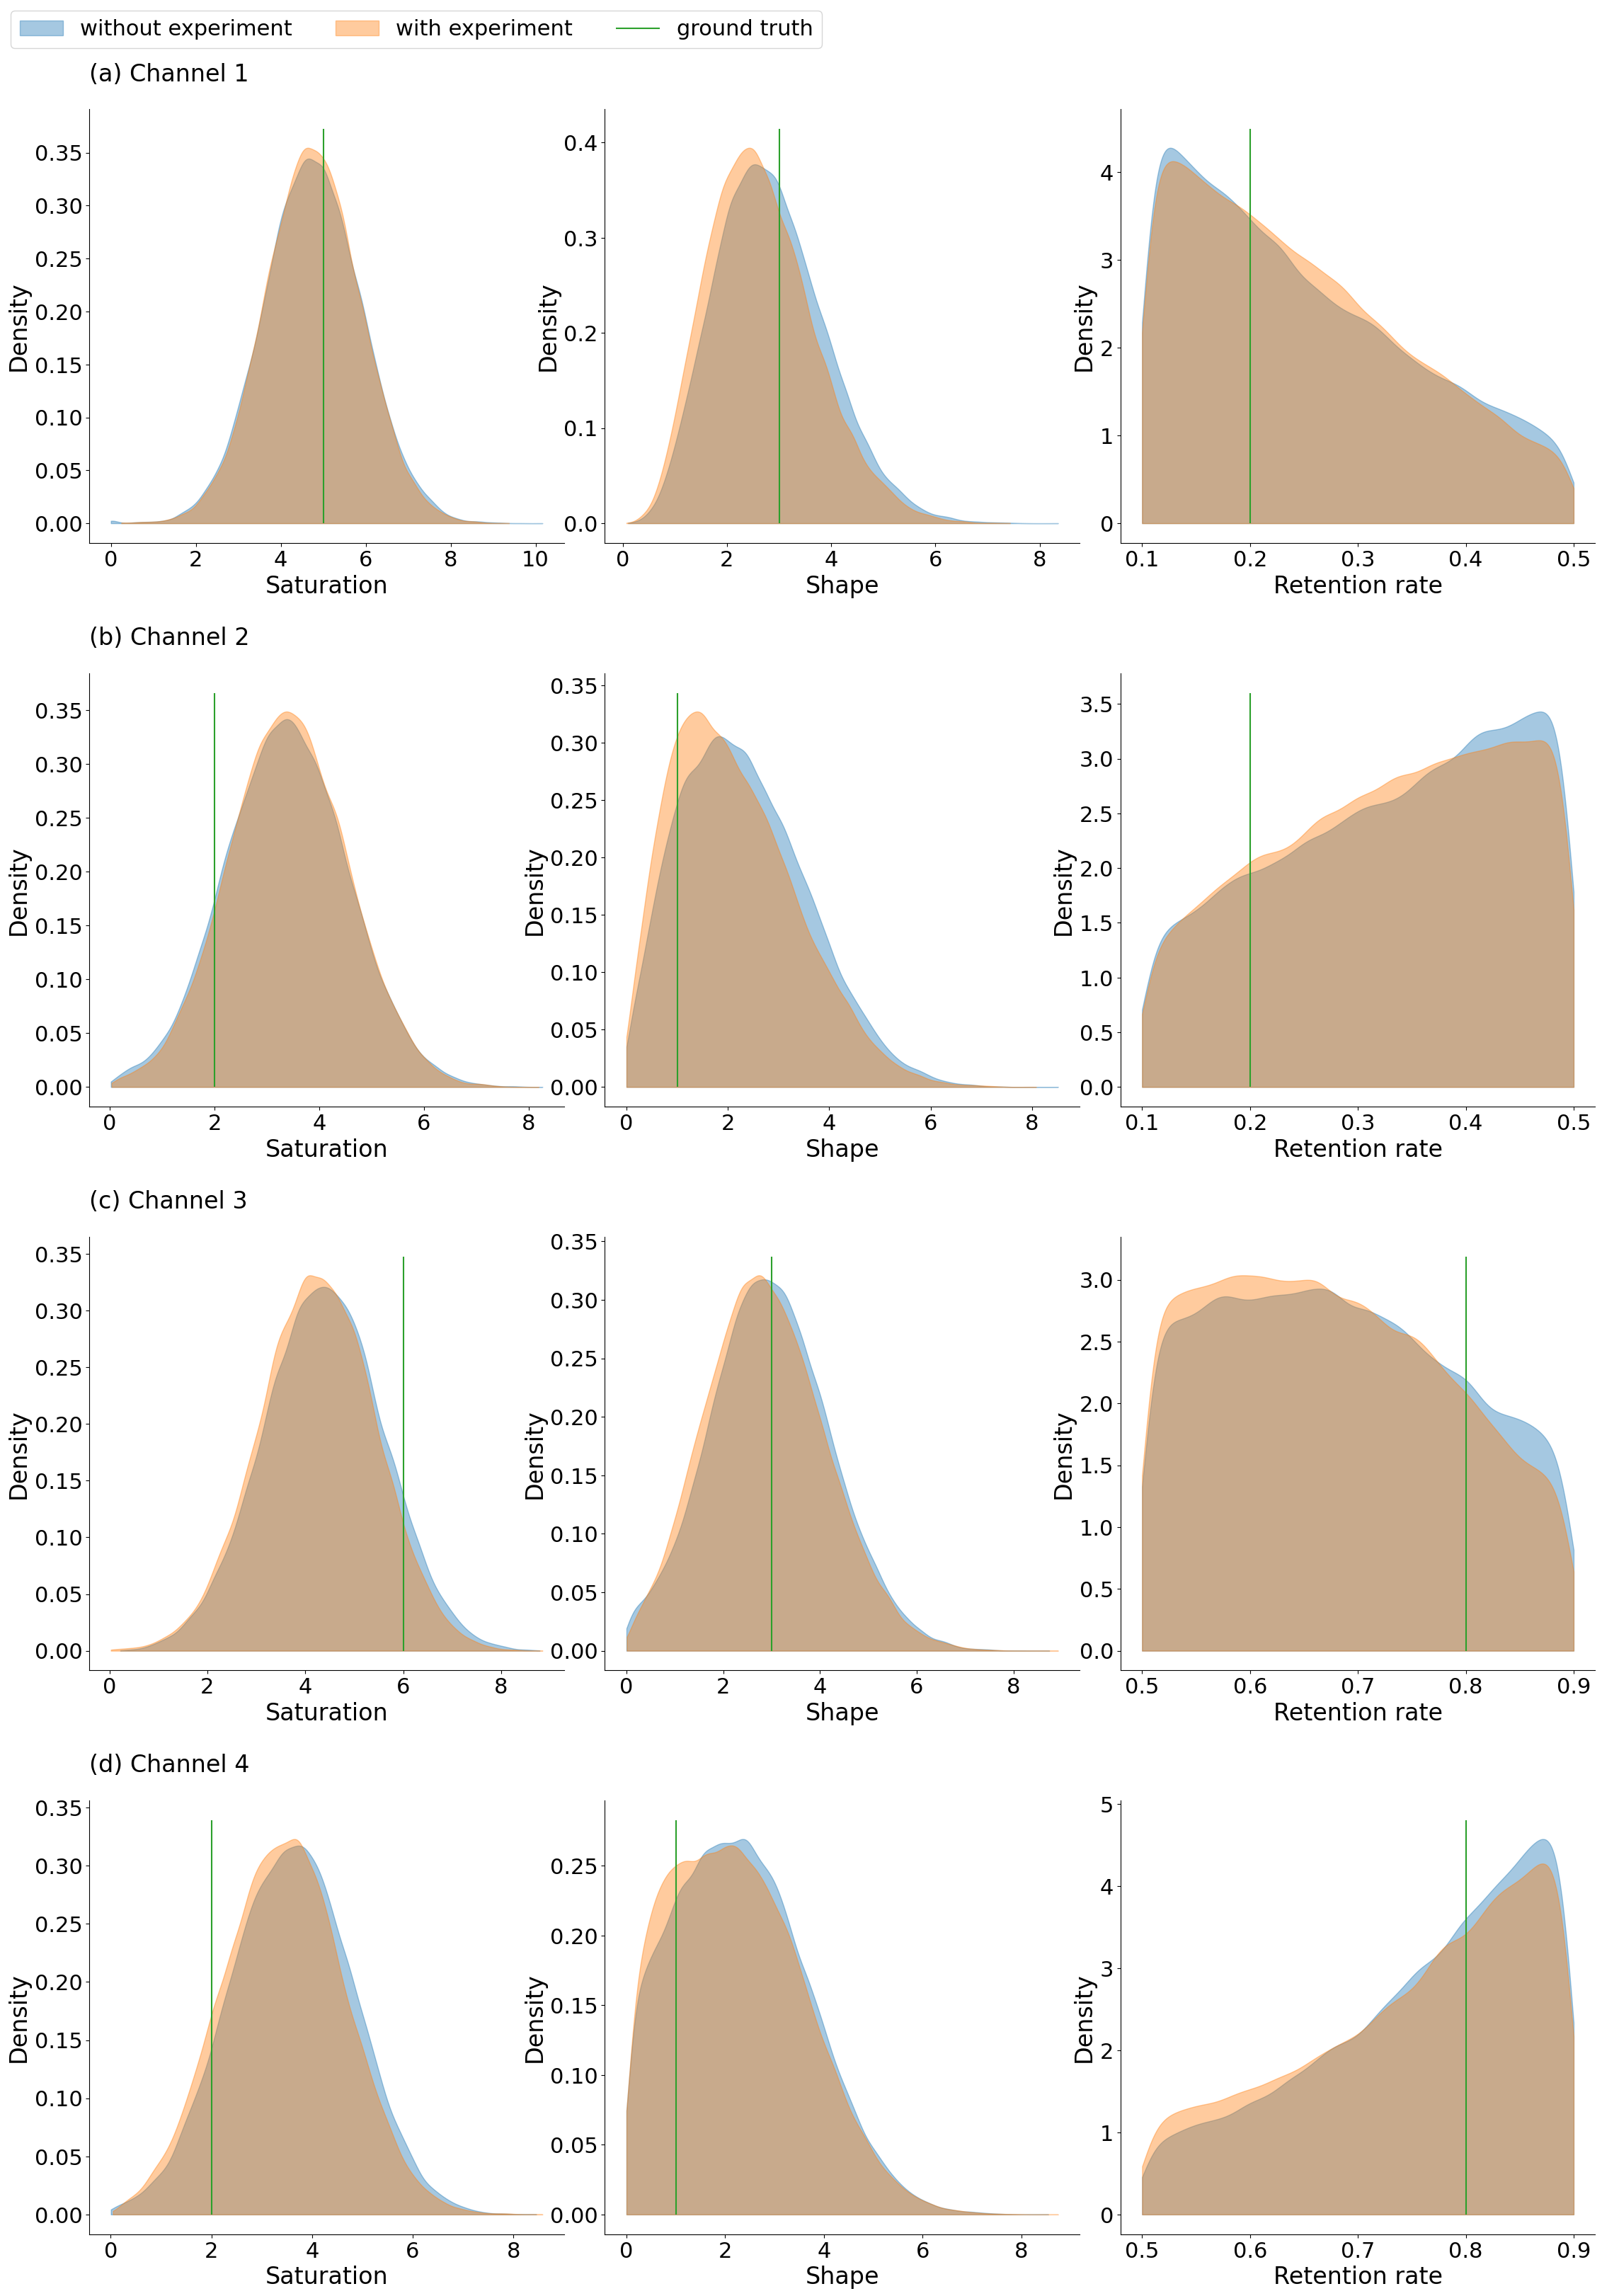

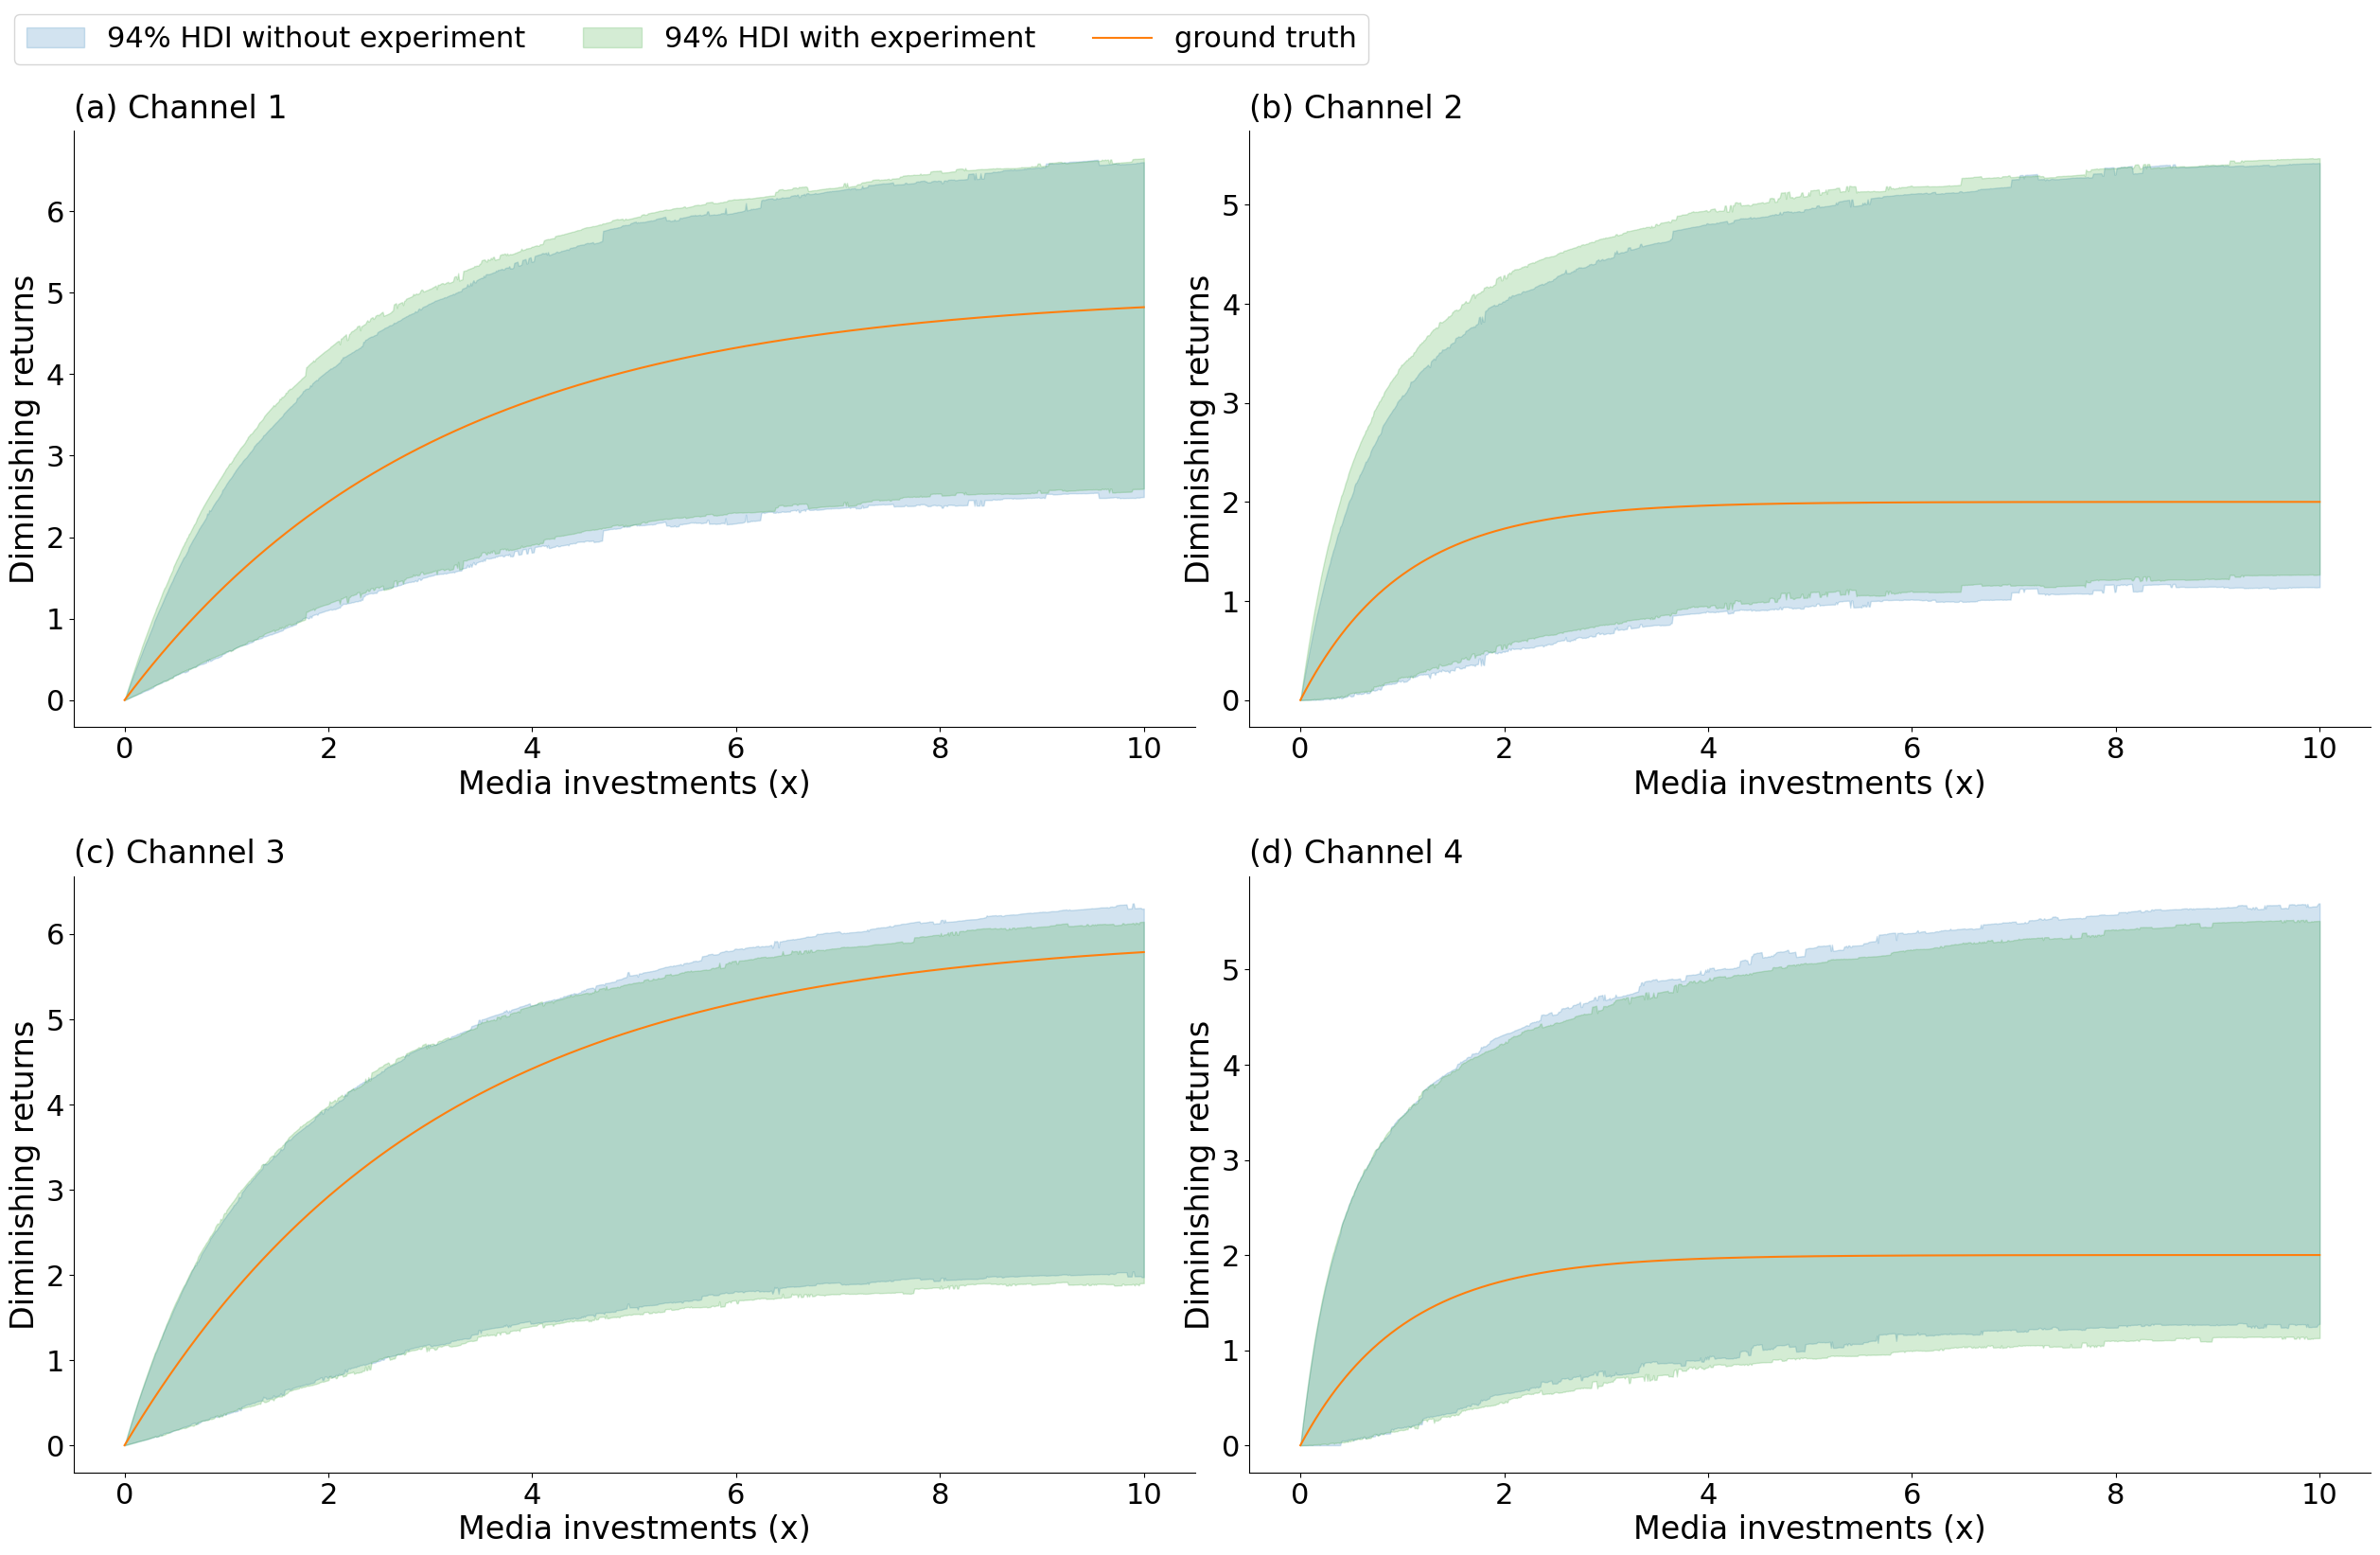

In [23]:
plot_experiment_posterior_vs_ground_truth(
    idata_without_experiment=idata_without_dhat,
    idata_with_experiment=idata_with_dhat_retention_rate,
    media_param_df=media_param_df,
    media_feature_names=["media_0", "media_1", "media_2", "media_3"],
    figsize=(22, 32),
    subplot_adjust_kwargs={"top": 0.95, "hspace": 0.3},
)

plot_experiment_posterior_response_curve_multiple(
    idata_without_experiment=idata_without_dhat,
    idata_with_experiment=idata_with_dhat_retention_rate,
    media_param_df=media_param_df,
    media_feature_names=["media_0", "media_1", "media_2", "media_3"],
)